In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

In [12]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [13]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [14]:
train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [15]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [16]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: xlabel='Survived', ylabel='count'>

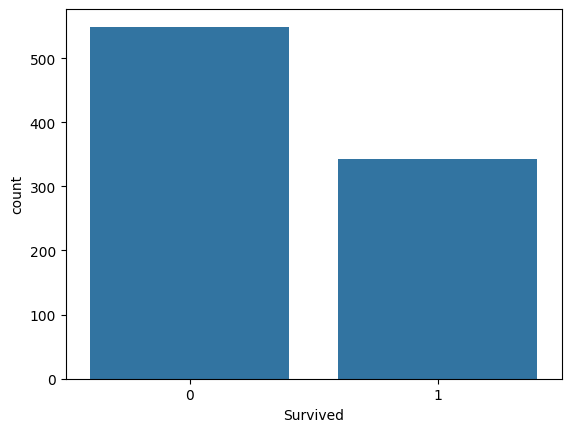

In [17]:
sns.countplot(x='Survived', data=train_df)

<Axes: ylabel='count'>

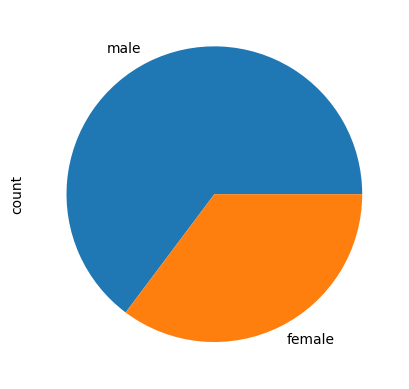

In [18]:
train_df['Sex'].value_counts().plot(kind='pie')

(array([100., 346., 188.,  69.,  11.]),
 array([ 0.42 , 16.336, 32.252, 48.168, 64.084, 80.   ]),
 <BarContainer object of 5 artists>)

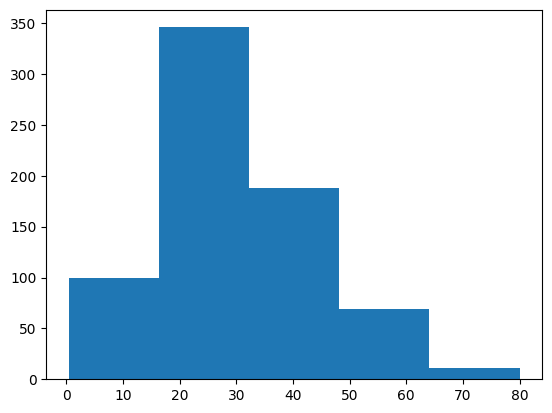

In [19]:
plt.hist(train_df['Age'],bins=5)

In [20]:
from ydata_profiling import ProfileReport

prof = ProfileReport(train_df, title="Pandas Profiling Report", explorative=True)

prof.to_file("output.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 140.43it/s]


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Drop the completely useless "noise" columns right away
df = train_df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# 2. Separate your Target (y) from your Features (X)
X = df.drop(columns=['Survived'])
y = df['Survived']

# 3. Split the data FIRST (This prevents "Data Leakage")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- START OF THE MACHINE ---

# 4. Define the rules for Numeric columns (Age, SibSp, Parch, Fare)
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')) # Fill missing with median
])

# 5. Define the rules for Categorical columns (Sex, Embarked)
categorical_features = ['Sex', 'Embarked']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Fill missing with mode
    ('onehot', OneHotEncoder(handle_unknown='ignore'))    # Convert text to numbers
])

# 6. Combine them using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 7. Create the final master Pipeline (Preprocessor + Model)
my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# --- END OF THE MACHINE ---

# 8. Train the whole pipeline at once!
my_pipeline.fit(X_train, y_train)

# 9. Make predictions (the pipeline automatically cleans X_test for you!)
predictions = my_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.8212290502793296


In [22]:
# 1. We need to save the PassengerId column before we drop it,
# because Kaggle requires it for the final submission format.
test_passenger_ids = test_df['PassengerId']

# 2. Drop the exact same "noise" columns from the test set
X_unseen = test_df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# 3. Feed the unseen data to your pipeline.
# It will automatically fill missing values, encode text, and predict!
final_predictions = my_pipeline.predict(X_unseen)

# 4. Create a new dataframe with exactly what Kaggle asks for
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': final_predictions
})

# 5. Save it as a CSV file (index=False prevents pandas from adding an extra column of row numbers)
submission.to_csv('titanic_submission.csv', index=False)
print("Submission saved successfully!")

Submission saved successfully!
